In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Load datasets

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

investor = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
# Convert date columns

nav["date"] = pd.to_datetime(nav["date"])

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

portfolio["portfolio_date"] = pd.to_datetime(
    portfolio["portfolio_date"]
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [4]:
print(nav.shape)
print(investor.shape)
print(fund_master.shape)
print(portfolio.shape)

(46000, 3)
(32778, 13)
(40, 15)
(322, 8)


In [5]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [6]:
# Sort by Fund and Date

nav = nav.sort_values(["amfi_code", "date"])

# Daily Return

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [7]:
# Historical VaR (95%) and CVaR

risk_metrics = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    # 95% Historical VaR (5th percentile)
    var95 = np.percentile(returns, 5)

    # CVaR = Average of returns below VaR
    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append({
        "amfi_code": code,
        "VaR_95": round(var95, 4),
        "CVaR_95": round(cvar95, 4)
    })

risk_metrics = pd.DataFrame(risk_metrics)

risk_metrics.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.0144,-0.0181
1,100025,-0.0038,-0.0050
2,100033,-0.0190,-0.0235
3,101206,-0.0133,-0.0174
4,101207,-0.0260,-0.0325


In [8]:
risk_metrics = risk_metrics.sort_values("VaR_95")

risk_metrics.head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.0269,-0.0324
17,119095,-0.0262,-0.0317
4,101207,-0.0260,-0.0325
11,118634,-0.0254,-0.0323
21,119598,-0.0245,-0.0306
39,149324,-0.0235,-0.0310
7,102886,-0.0192,-0.0233
2,100033,-0.0190,-0.0235
25,120505,-0.0189,-0.0243
16,119094,-0.0185,-0.0243


In [9]:
risk_metrics.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [10]:
# Load Fund Scorecard

fund_scorecard = pd.read_csv("../reports/fund_scorecard.csv")

top5_codes = fund_scorecard.head(5)["amfi_code"].tolist()

print(top5_codes)

[148567, 120843, 120505, 100033, 120504]


In [11]:
# Filter Top 5 Funds

top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav.shape

(5750, 4)

In [12]:
# Rolling 90-Day Sharpe Ratio

top5_nav["Rolling_Sharpe"] = (
    top5_nav.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

top5_nav.head(100)

,amfi_code,date,nav,daily_return,Rolling_Sharpe
2300,100033,2022-01-03,107.3758,NaN,NaN
2301,100033,2022-01-04,105.9447,-0.013328,NaN
2302,100033,2022-01-05,105.4800,-0.004386,NaN
2303,100033,2022-01-06,104.9350,-0.005167,NaN
2304,100033,2022-01-07,104.3318,-0.005748,NaN
...,...,...,...,...,...
2395,100033,2022-05-16,94.8770,0.000373,-1.432745
2396,100033,2022-05-17,95.6569,0.008220,-1.329065
2397,100033,2022-05-18,97.6478,0.020813,-0.956879
2398,100033,2022-05-19,98.0226,0.003838,-0.942304


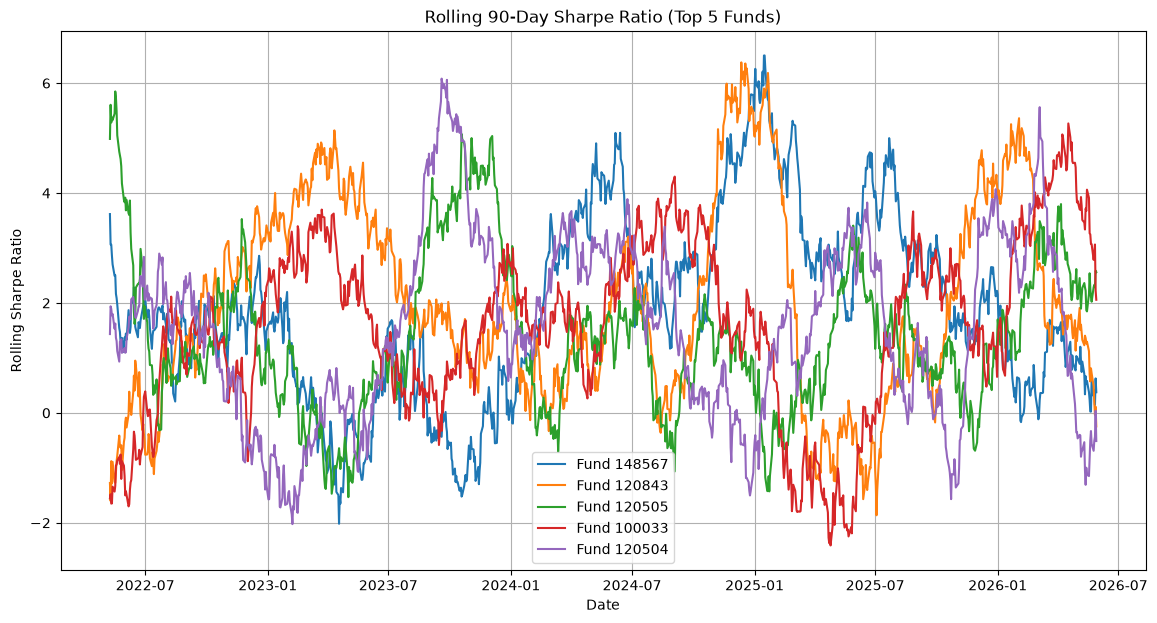

In [13]:
plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund = top5_nav[top5_nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["Rolling_Sharpe"],
        label=f"Fund {code}"
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Find first transaction date for each investor

first_transaction = (
    investor.groupby("investor_id")["transaction_date"]
            .min()
            .reset_index()
)

first_transaction.rename(
    columns={"transaction_date": "first_transaction_date"},
    inplace=True
)

first_transaction.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [15]:
# Extract Cohort Year

first_transaction["cohort_year"] = (
    first_transaction["first_transaction_date"].dt.year
)

first_transaction.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [16]:
# Merge cohort year into investor dataset

investor = investor.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [17]:
# Filter only SIP transactions

sip_data = investor[investor["transaction_type"] == "SIP"]

cohort_summary = (
    sip_data.groupby("cohort_year")
            .agg(
                Average_SIP_Amount=("amount_inr", "mean"),
                Total_Invested=("amount_inr", "sum"),
                SIP_Transactions=("amount_inr", "count")
            )
            .reset_index()
)

cohort_summary["Average_SIP_Amount"] = cohort_summary["Average_SIP_Amount"].round(2)

cohort_summary

,cohort_year,Average_SIP_Amount,Total_Invested,SIP_Transactions
0,2024,10996.89,214978121,19549
1,2025,13505.21,2255370,167


In [18]:
# Most preferred fund in each cohort

top_fund = (
    sip_data.groupby(["cohort_year", "amfi_code"])
            .size()
            .reset_index(name="Count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "Count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,Count
24,2024,120504,536
62,2025,119599,8


In [19]:
# Add Scheme Name

top_fund = top_fund.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund

,cohort_year,amfi_code,Count,scheme_name
0,2024,120504,536,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,119599,8,SBI Small Cap Fund - Direct Plan - Growth


In [20]:
# Final Cohort Analysis

cohort_analysis = cohort_summary.merge(
    top_fund[["cohort_year", "scheme_name"]],
    on="cohort_year",
    how="left"
)

cohort_analysis.rename(
    columns={
        "scheme_name": "Top_Fund_Preference"
    },
    inplace=True
)

cohort_analysis

,cohort_year,Average_SIP_Amount,Total_Invested,SIP_Transactions,Top_Fund_Preference
0,2024,10996.89,214978121,19549,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,13505.21,2255370,167,SBI Small Cap Fund - Direct Plan - Growth


In [21]:
# Filter only SIP transactions

sip_only = investor[
    investor["transaction_type"] == "SIP"
].copy()

sip_only = sip_only.sort_values(
    ["investor_id", "transaction_date"]
)

sip_only.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [22]:
# Days between consecutive SIPs

sip_only["Gap_Days"] = (
    sip_only.groupby("investor_id")["transaction_date"]
            .diff()
            .dt.days
)

sip_only.head(15)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,Gap_Days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [23]:
# Days between consecutive SIPs

sip_only["Gap_Days"] = (
    sip_only.groupby("investor_id")["transaction_date"]
            .diff()
            .dt.days
)

sip_only.head(15)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,Gap_Days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [24]:
sip_continuity = (
    sip_only.groupby("investor_id")
            .agg(
                SIP_Count=("transaction_date", "count"),
                Average_Gap_Days=("Gap_Days", "mean")
            )
            .reset_index()
)

# Keep only investors with 6 or more SIPs

sip_continuity = sip_continuity[
    sip_continuity["SIP_Count"] >= 6
]

sip_continuity["Average_Gap_Days"] = (
    sip_continuity["Average_Gap_Days"].round(1)
)

sip_continuity.head()

,investor_id,SIP_Count,Average_Gap_Days
3,INV000004,6,85.4
7,INV000008,6,70.4
9,INV000010,6,64.8
10,INV000011,7,40.2
11,INV000012,8,57.0


In [25]:
sip_continuity["Status"] = np.where(
    sip_continuity["Average_Gap_Days"] > 35,
    "At Risk",
    "Healthy"
)

sip_continuity.head(10)

,investor_id,SIP_Count,Average_Gap_Days,Status
3,INV000004,6,85.4,At Risk
7,INV000008,6,70.4,At Risk
9,INV000010,6,64.8,At Risk
10,INV000011,7,40.2,At Risk
11,INV000012,8,57.0,At Risk
12,INV000013,7,55.3,At Risk
13,INV000014,7,75.3,At Risk
22,INV000023,8,58.6,At Risk
27,INV000028,6,93.6,At Risk
28,INV000029,7,60.7,At Risk


In [26]:
sip_continuity["Status"].value_counts()


Status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [27]:
# Load Fund Scorecard

scorecard = pd.read_csv("../reports/fund_scorecard.csv")

scorecard.head()

,amfi_code,scheme_name,expense_ratio_pct,3Y CAGR (%),Sharpe_Ratio,Alpha,Maximum_Drawdown (%),Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,33.99,1.4483,0.2698,-11.27,2.0,1.0,7.0,20.0,8.0,87.38
1,120843,Kotak Flexicap Fund - Regular - Growth,1.45,29.58,1.3067,0.2733,-12.97,7.0,2.0,5.0,19.0,13.0,83.12
2,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,31.77,1.1801,0.2926,-18.19,5.0,5.0,3.0,14.0,25.0,82.62
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,32.43,1.0937,0.2720,-16.22,4.0,7.0,6.0,15.0,20.0,81.50
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,32.48,1.0265,0.2119,-12.59,3.0,10.0,13.0,11.0,12.0,80.38


In [28]:
# Merge with Fund Master

recommendation_data = scorecard.merge(
    fund_master[
        ["amfi_code", "scheme_name", "risk_category"]
    ],
    on="amfi_code",
    how="left"
)

recommendation_data.head()

,amfi_code,scheme_name_x,expense_ratio_pct,3Y CAGR (%),Sharpe_Ratio,Alpha,Maximum_Drawdown (%),Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score,scheme_name_y,risk_category
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,33.99,1.4483,0.2698,-11.27,2.0,1.0,7.0,20.0,8.0,87.38,Mirae Asset Large Cap Fund - Regular - Growth,Moderate
1,120843,Kotak Flexicap Fund - Regular - Growth,1.45,29.58,1.3067,0.2733,-12.97,7.0,2.0,5.0,19.0,13.0,83.12,Kotak Flexicap Fund - Regular - Growth,Moderately High
2,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,31.77,1.1801,0.2926,-18.19,5.0,5.0,3.0,14.0,25.0,82.62,ICICI Pru Midcap Fund - Regular - Growth,High
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,32.43,1.0937,0.2720,-16.22,4.0,7.0,6.0,15.0,20.0,81.50,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,32.48,1.0265,0.2119,-12.59,3.0,10.0,13.0,11.0,12.0,80.38,ICICI Pru Bluechip Fund - Direct - Growth,Moderate


In [29]:
recommendation_data["risk_category"].unique()

<StringArray>
['Moderate', 'Moderately High', 'High', 'Very High', 'Low']
Length: 5, dtype: str

In [ ]:
def recommend_funds(risk_level):

    recommendations = (
        recommendation_data[
            recommendation_data["risk_category"] == risk_level
        ]
        .sort_values("Sharpe_Ratio", ascending=False)
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "risk_category",
            "Sharpe_Ratio",
            "Fund_Score"
        ]
    ]